In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_models import *

dq.set_device('cpu')
import warnings
warnings.filterwarnings("ignore")

In [2]:
solver = dq.solver.Tsit5(
                    rtol= 1e-06,
                    atol= 1e-06,
                    safety_factor= 0.9,
                    min_factor= 0.2,
                    max_factor = 5.0,
                    max_steps = int(1e4*1000),
                )

n_lvls_fluxonium = 20
n_lvls_transmon = 4


Ej_f = 2.7
Ec_f = 0.6
El_f = 0.13
qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": Ej_f, "Ec": Ec_f, "El": El_f, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )
g_tf = 0.2
Ec_t = 0.2


def truncate(data: jnp.array):
    return data[:,:]

tot_dim = 80


In [3]:

def objective(params):    
    sigma = params[0]
    amp_with_2pi = params[1]
    Ej_t = params[2]
    w_d = params[3]
    beta = params[4]
    
    Ec_t = 0.2
    qst = MyTransmon.create(
        N = n_lvls_transmon,
        params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
        N_max_charge=10
        )
    

    devices = [qsf, qst]
    f_indx = 0
    t_indx = 1
    Ns = [device.N for device in devices]
    fn = qs.promote(qsf.ops["n"], f_indx, Ns)
    tn = qs.promote(qst.ops['n'], t_indx, Ns)

    g_tf = 0.2
    system = qs.System.create(devices, couplings=[
        g_tf *  fn @ tn
        ])
    system.params["g_tf"] = g_tf
    system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
    driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)
    # system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
    # w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]


    pulse_length = 5*sigma
    pulse_shape_args={
        'w_d': w_d,
        'amp': amp_with_2pi/(2*jnp.pi),
        'duration': pulse_length,
        'sigma': sigma,
        'beta':beta
    }      

    t_tot = pulse_length 
    tlist = jnp.array([0,t_tot])

    def _H(t):
        _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
        _H += truncate(driven_op) * modified_drag_pulse(t, pulse_shape_args)
        return _H 
    H =  dq.timecallable(_H)
    
    psi0_list = [truncate(dq.basis(tot_dim,find_closest_dressed_index(l*qst.N, product_indices_sorted_by_eval)))
                        for l in [0,1,2]] #00,10,20
    result = dq.sesolve(
                H = H,
                psi0 = psi0_list,
                tsave = tlist,
                solver = solver
                )
        
    f0_e = dq.expect(dq.basis_dm(tot_dim, find_closest_dressed_index(0*qst.N+1, product_indices_sorted_by_eval)),
                    result.states[0][-1]).real
    
    f1_e = dq.expect(dq.basis_dm(tot_dim, find_closest_dressed_index(1*qst.N+1, product_indices_sorted_by_eval)),
                    result.states[1][-1]).real
    
    f2_e = dq.expect(dq.basis_dm(tot_dim, find_closest_dressed_index(2*qst.N+1, product_indices_sorted_by_eval)),
                    result.states[2][-1]).real
    
    return 1 - f0_e + f1_e + f2_e

func = jax.value_and_grad(objective)



In [4]:
sigma = 2.47029937e+02 / np.sqrt(2*np.pi)
amp_with_2pi = 9.13069185e-03
Ej_t =  3.40890048e+01
w_d = 7.17878953
beta = 0.1
params =  jnp.array([
                sigma,
                amp_with_2pi,
                Ej_t,
                w_d,
                beta
            ])



In [5]:


optimizer = optax.nadam(learning_rate=jnp.array([2,
                                                 0.01,
                                                 0.1,
                                                 0.5,
                                                 0.1])) 
opt_state = optimizer.init(params)

num_steps = 1000
for step in range(num_steps):
    val, grads = func(params)
    print(f"iter: {step}, val={val:.4f} grads: {grads}, params: {params}")
    if val < 1e-4:
        break
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

print(f'Optimized params: {params}')

iter: 0, val=0.9689 grads: [ 3.16794592e-03  5.04055353e+00 -8.91055719e+00  9.48805250e+01
  1.38238803e-03], params: [9.85506864e+01 9.13069185e-03 3.40890048e+01 7.17878953e+00
 1.00000000e-01]
iter: 1, val=1.0000 grads: [-1.89030738e-12 -6.72279033e-11 -3.24480608e-11  2.73445085e-10
  4.68251967e-15], params: [ 9.56033273e+01 -5.60615023e-03  3.42363732e+01  6.44194742e+00
 -4.73673550e-02]
iter: 2, val=1.0000 grads: [-9.92395669e-12 -3.25173732e-11 -9.25448329e-11  9.23277907e-10
  1.64558624e-14], params: [ 9.47577225e+01 -9.83419307e-03  3.42786536e+01  6.23054528e+00
 -8.96473510e-02]
iter: 3, val=1.0000 grads: [ 3.34711278e-12 -3.20671939e-11  3.79438858e-11 -3.15423401e-10
 -5.58298029e-15], params: [ 9.40230379e+01 -1.35076361e-02  3.43153881e+01  6.04687313e+00
 -1.26381321e-01]
iter: 4, val=1.0000 grads: [ 8.64536305e-12  5.49345990e-12  5.46521840e-11 -5.56695367e-10
 -1.03330169e-14], params: [ 9.33816972e+01 -1.67143598e-02  3.43474553e+01  5.88653695e+00
 -1.58448093e

KeyboardInterrupt: 

In [3]:
sigma = 2.47029937e+02 / np.sqrt(2*np.pi)
amp_with_2pi = 9.13069185e-03
Ej_t =  3.40890048e+01
w_d = 7.17878953
beta = 0.4
params =  jnp.array([
                sigma,
                amp_with_2pi,
                Ej_t,
                w_d,
                beta
            ])
sigma = params[0]
amp_with_2pi = params[1]
Ej_t = params[2]
w_d = params[3]
beta = params[4]



Ec_t = 0.2
qst = MyTransmon.create(
    N = n_lvls_transmon,
    params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
    N_max_charge=10
    )


devices = [qsf, qst]
f_indx = 0
t_indx = 1
Ns = [device.N for device in devices]
fn = qs.promote(qsf.ops["n"], f_indx, Ns)
tn = qs.promote(qst.ops['n'], t_indx, Ns)

g_tf = 0.2
system = qs.System.create(devices, couplings=[
    g_tf *  fn @ tn
    ])
system.params["g_tf"] = g_tf
system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)
# system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
# w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]


pulse_length = 6*sigma
pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*jnp.pi),
    'duration': pulse_length,
    'sigma': sigma,
    'beta':beta
}      

t_tot = pulse_length 
tlist = jnp.array([0,t_tot])

def _H(t):
    _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
    _H += truncate(driven_op) * modified_drag_pulse(t, pulse_shape_args)
    return _H 
H =  dq.timecallable(_H)

psi0_list = [truncate(dq.basis(tot_dim,find_closest_dressed_index(l*qst.N, product_indices_sorted_by_eval)))
                    for l in [0,1,2]] #00,10,20


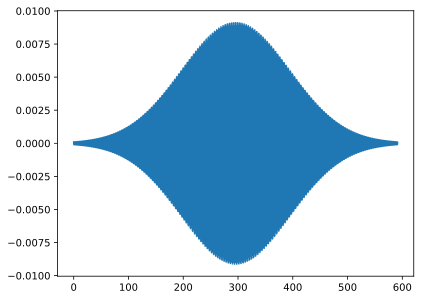

In [4]:
times = np.linspace(0,pulse_length,int(pulse_length*10))
plt.plot(times, modified_drag_pulse(times, pulse_shape_args ))
# plt.plot(square_pulse_with_rise_fall(np.linspace(0,t_tot,int(t_tot*10)), pulse_shape_args_square))

# system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
# w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
# print(w_d)

(-1e-05, 0.0001)

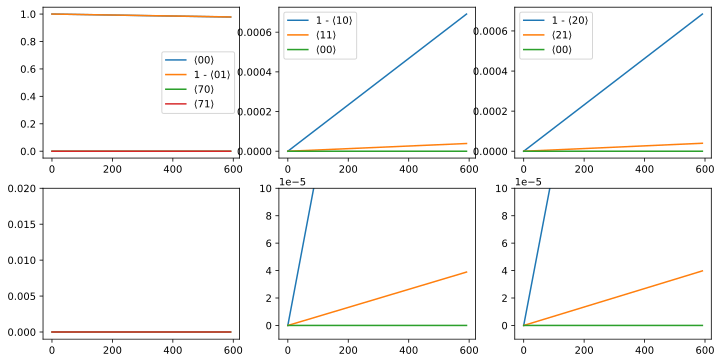

In [5]:


e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(truncate(dq.basis_dm(math.prod(Ns),  find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval))))

result = dq.sesolve(
            H = H,
            psi0 = psi0_list,
            tsave = tlist,
            solver = solver,
            exp_ops = e_ops
            )

colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1)],
                        [(1,0),(1,1),(0,0)],
                        [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,result.expects[col][i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - result.expects[col][i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-3,2e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)
